In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image  # for medical images
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
data_dir = "/content/drive/MyDrive/brain_tumor_dataset"

classes = ["yes", "no"]
data = []

for label in classes:
  folder = os.path.join(data_dir, label)
  for file in os.listdir(folder):
    data.append((os.path.join(folder, file), label))
df = pd.DataFrame  (data, columns = ["image_path", "label"])
print(df.head() ,"/n")
print("Dataset Size", df.shape)

In [ ]:
df.head()

,image_path,label
0,/content/drive/MyDrive/brain_tumor_dataset/yes...,yes
1,/content/drive/MyDrive/brain_tumor_dataset/yes...,yes
2,/content/drive/MyDrive/brain_tumor_dataset/yes...,yes
3,/content/drive/MyDrive/brain_tumor_dataset/yes...,yes
4,/content/drive/MyDrive/brain_tumor_dataset/yes...,yes


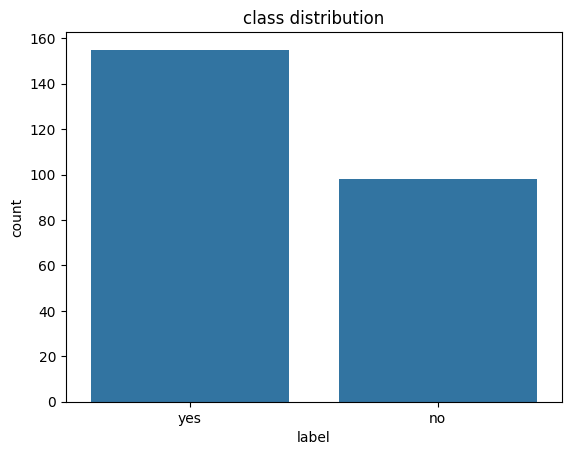

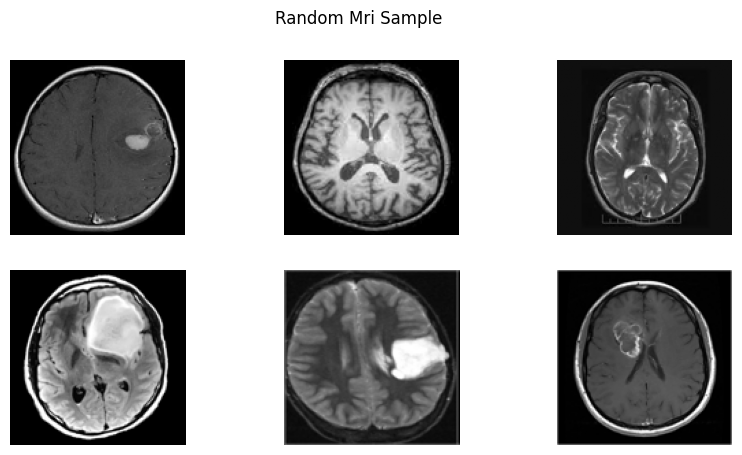

In [ ]:
sns.countplot(x = "label", data=df)
plt.title("class distribution")
plt.show()

plt.figure(figsize = (10, 5))

for i in range(6):
  row = df.sample(1).iloc[0]
  img = Image.open(row.image_path).convert("L")
  img = img.resize((128, 128))
  plt.subplot(2, 3, i + 1)
  plt.imshow(img, cmap = "gray")
  plt.axis("off")
plt.suptitle("Random Mri Sample")
plt.show()


In [ ]:
IMG_SIZE = (128, 128)

X, y = [], []

for row in df.itertuples(index = False):
  img = Image.open(row.image_path).convert("L")
  img = img.resize(IMG_SIZE)
  img_arr = np.array(img)/255.0
  X.append(img_arr)
  y.append(1 if row.label == "yes" else 0)

X = np.array(X)
y = np.array(y)
print("X shape", X.shape, "y shape", y.shape)

X_cnn = X.reshape(-1, 128, 128, 1)

X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_cnn, y, test_size = 0.2, random_state = 42)

X shape (253, 128, 128) y shape (253,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_ml = X.reshape(len(X), -1)
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y, test_size = 0.2, random_state = 42)

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train_ml, y_train_ml)

y_pred_rf = rf.predict(X_test_ml)

print("/nRandon Forest Classifier: ", accuracy_score(y_test_ml, y_pred_rf))

print(classification_report(y_test_ml, y_pred_rf))

/nRandon Forest Classifier:  0.7843137254901961
              precision    recall  f1-score   support

           0       0.88      0.62      0.73        24
           1       0.74      0.93      0.82        27

    accuracy                           0.78        51
   macro avg       0.81      0.78      0.78        51
weighted avg       0.80      0.78      0.78        51



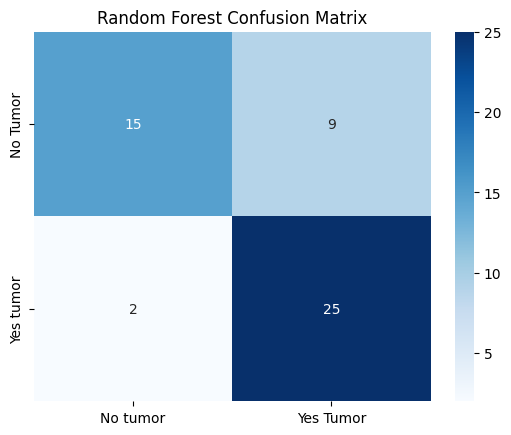

In [ ]:
cm_rf = confusion_matrix(y_test_ml, y_pred_rf)
sns.heatmap(cm_rf, annot = True, fmt = "d", cmap="Blues", xticklabels=['No tumor', 'Yes Tumor'],
            yticklabels=['No Tumor', 'Yes tumor'])
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
cnn=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(128,128,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
datagen = ImageDataGenerator(rotation_range = 20, width_shift_range = 0.1, height_shift_range = 0.1
, zoom_range = 0.1, horizontal_flip = True, fill_mode = "nearest")

datagen.fit(X_train_cnn)

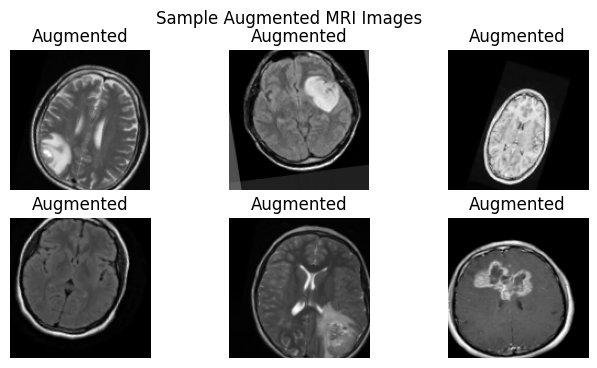

In [ ]:
plt.figure(figsize = (8, 4))

for X_batch, y_batch in datagen.flow(X_train_cnn, y_train, batch_size = 6, shuffle = True):

  for i in range(6):
    plt.subplot(2,3, i+1)
    plt.imshow(X_batch[i].reshape(128, 128), cmap = "gray")
    plt.title("Augmented")
    plt.axis("off")
  break
plt.suptitle("Sample Augmented MRI Images")
plt.show()

In [ ]:
history = cnn.fit(datagen.flow(X_train_cnn, y_train, batch_size = 32), epochs = 20, validation_data = (X_test_cnn, y_test))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 764ms/step - accuracy: 0.8038 - loss: 0.4982 - val_accuracy: 0.7255 - val_loss: 0.6747
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 697ms/step - accuracy: 0.7840 - loss: 0.4777 - val_accuracy: 0.7255 - val_loss: 0.5995
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 923ms/step - accuracy: 0.7476 - loss: 0.5070 - val_accuracy: 0.7059 - val_loss: 0.5943
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 646ms/step - accuracy: 0.7903 - loss: 0.4935 - val_accuracy: 0.6667 - val_loss: 0.7148
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 927ms/step - accuracy: 0.7871 - loss: 0.4705 - val_accuracy: 0.6667 - val_loss: 0.6667
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 699ms/step - accuracy: 0.7822 - loss: 0.4836 - val_accuracy: 0.6667 - val_loss: 0.6887
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 707ms/step - accuracy: 0.7644 - loss: 0.5022 - val_accuracy: 0.7843 - val_loss: 0.5210
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 778ms/step - accuracy: 0.7921 - loss: 0.5031 - val_accuracy: 0.7451 - val_loss

In [ ]:
loss, acc = cnn.evaluate(X_test_cnn, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.7467 - loss: 0.5603
Test Accuracy: 0.7450980544090271


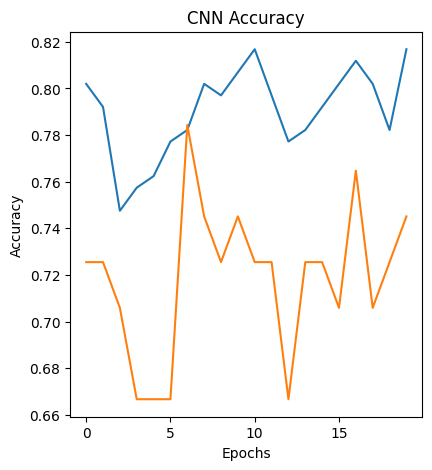

In [ ]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Train Acc")
plt.plot(history.history["val_accuracy"], label = "Validation Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.show()

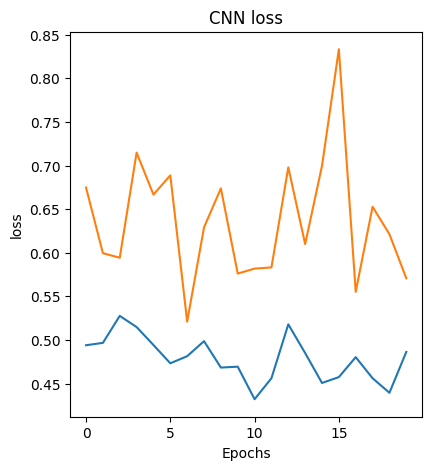

In [ ]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "Train loss")
plt.plot(history.history["val_loss"], label = "Validation loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("CNN loss")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlabels'

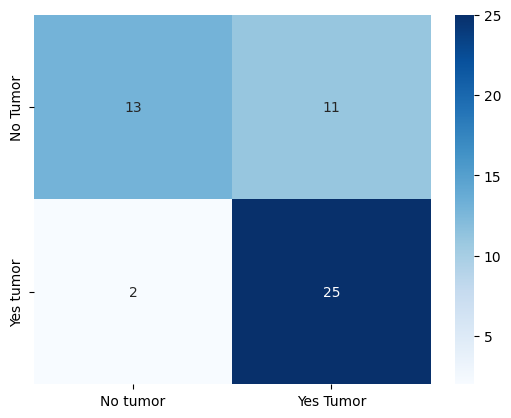

In [ ]:
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int).flatten()

cm_cnn = (confusion_matrix(y_test, y_pred_cnn))

sns.heatmap(cm_cnn, annot = True, fmt = "d", cmap="Blues", xticklabels=['No tumor', 'Yes Tumor'],
            yticklabels=['No Tumor', 'Yes tumor'])
plt.xlabels("Predicted");plt.ylabels("aactual");plt.title("CNN Confusion Matrix")
plt.show()
#